In [1]:
import sys
from pathlib import Path
import joblib

Duong_Dan_Goc = Path(r"D:\HR Analytics")
sys.path.append(str(Duong_Dan_Goc/"python"/"src"))

import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from db import get_engine

MODEL_DIR = Duong_Dan_Goc / "python" / "models"
OUTPUT_DIR = Duong_Dan_Goc / "python" / "outputs"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)   


In [2]:
engine = get_engine()
query="""
select *
from dw.View_ML_NhanVien
order by NgayThang, MaNV
"""
df = pd.read_sql(query, engine)
df.head()

,MaNV,NgayThang,Nam,PhongBan,ChucDanh,CapBacCongViec,Tuoi,KhoangCachTuNha,SoLuongDuAn,SoGioTrungBinhThang,LamThemGio,DiemDanhGiaHieuSuat,DiemHaiLongCongViec,DiemHaiLongMoiTruong,ThuNhapThang,SoNamTaiCongTy,SoNamTuLanThangChucCuoi,DuocThangChucNamTruoc,CoNghiViec
0,5,2018-01-01,2018,Information Technology,IT Support,2,41,15,5,194,False,3,2,3,16936000,7,7,False,0
1,6,2018-01-01,2018,Sales,Sales Supervisor,1,29,16,3,206,False,4,4,3,11779000,7,7,False,0
2,7,2018-01-01,2018,Operations,Operations Manager,2,28,36,1,177,False,2,2,3,15588000,4,4,False,1
3,8,2018-01-01,2018,Human Resources,C&B Specialist,3,35,3,4,240,True,3,1,4,33357000,6,6,False,0
4,10,2018-01-01,2018,Human Resources,C&B Specialist,2,38,35,3,166,False,4,2,2,15353000,4,4,False,0


In [3]:
ngay_moi_nhat = df["NgayThang"].max()

df_latest = df[df["NgayThang"] == ngay_moi_nhat].copy()

print(ngay_moi_nhat)

2025-01-01


In [4]:
#Chọn features phù hợp và chuẩn hóa dữ liệu
features_kmeans = [
    "Tuoi",
    "KhoangCachTuNha",
    "SoLuongDuAn",
    "SoGioTrungBinhThang",
    "ThuNhapThang",
    "SoNamTaiCongTy",
    "SoNamTuLanThangChucCuoi",
    "CapBacCongViec"
]

X = df_latest[features_kmeans].copy()

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(X)

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
#Tìm cụm k bằng thuật toán Elbow và Silhouette

gia_tri_k = range(2, 9)

inertias = []
silhouettes = []

for k in gia_tri_k:
    mo_hinh = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    nhan = mo_hinh.fit_predict(x_scaled)

    inertias.append(mo_hinh.inertia_)
    silhouettes.append(
        silhouette_score(x_scaled, nhan)
    )

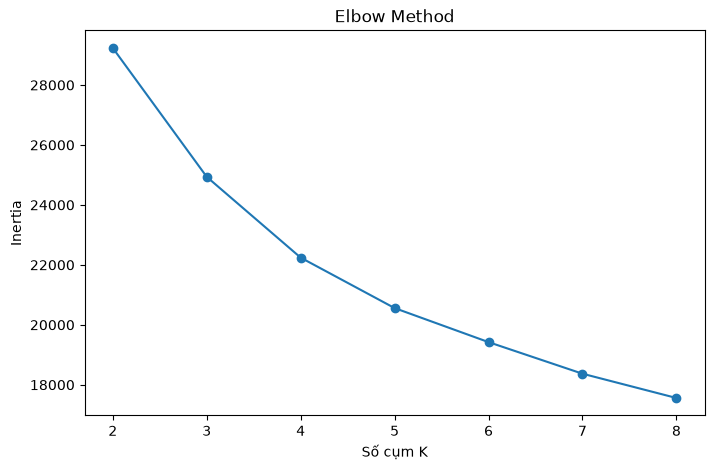

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(list(gia_tri_k), inertias, marker="o")
plt.xlabel("Số cụm K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

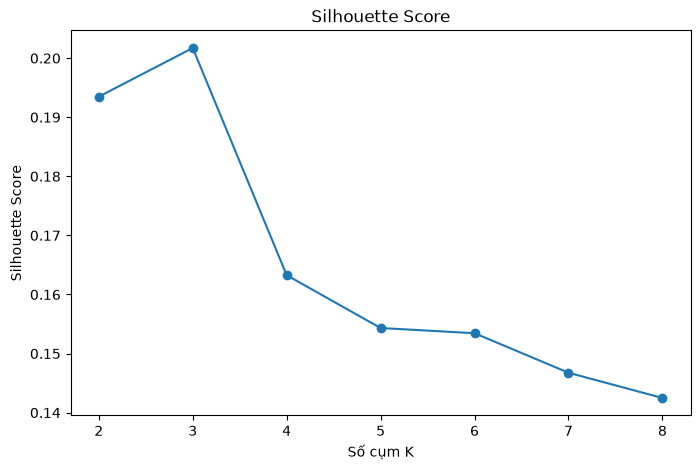

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(list(gia_tri_k), silhouettes, marker="o")
plt.xlabel("Số cụm K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

In [9]:
ket_qua_k = pd.DataFrame({
    "K": list(gia_tri_k),
    "Inertia": inertias,
    "Silhouette": silhouettes
})

ket_qua_k

,K,Inertia,Silhouette
0,2,29234.972709,0.193486
1,3,24936.511065,0.201720
2,4,22240.752808,0.163263
3,5,20558.369283,0.154325
4,6,19422.383101,0.153444
5,7,18368.677875,0.146755
6,8,17558.569282,0.142479


In [ ]:
#Huấn luyện mô hình K-Means với giá trị k là 3
k = 3
k_mean = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=20
)

df_latest["Cluster"] = k_mean.fit_predict(x_scaled)

df_latest[["MaNV", "Cluster"]].head()

,MaNV,Cluster
35210,1,0
35211,3,0
35212,4,0
35213,5,2
35214,10,2


In [11]:
#Kich thuoc cua moi cum
kich_thuoc_cum = (
    df_latest["Cluster"]
    .value_counts()
    .sort_index()
    .rename("SoNhanVien")
)

kich_thuoc_cum

Cluster
0    2472
1     866
2    1093
Name: SoNhanVien, dtype: int64

In [12]:
phan_bo_cum = pd.DataFrame({
    "SoNhanVien": kich_thuoc_cum
})

phan_bo_cum["TyLePhanTram"] = (
    phan_bo_cum["SoNhanVien"]
    / len(df_latest)
    * 100
).round(2)

phan_bo_cum

,SoNhanVien,TyLePhanTram
Cluster,,
0,2472,55.79
1,866,19.54
2,1093,24.67


In [13]:
print("Tong nhan vien:", phan_bo_cum["SoNhanVien"].sum())
print("Tong ty le:", phan_bo_cum["TyLePhanTram"].sum())

Tong nhan vien: 4431
Tong ty le: 100.0


In [13]:
#Dac trung thuc te
dac_trung_cum = (
    df_latest
    .groupby("Cluster")[features_kmeans]
    .mean()
    .round(2)
)

dac_trung_cum

,Tuoi,KhoangCachTuNha,SoLuongDuAn,SoGioTrungBinhThang,ThuNhapThang,SoNamTaiCongTy,SoNamTuLanThangChucCuoi,CapBacCongViec
Cluster,,,,,,,,
0,37.15,20.85,3.49,198.17,16647784.79,3.04,2.28,1.74
1,44.18,20.00,3.61,200.20,22307137.41,10.76,8.61,1.80
2,40.13,20.28,3.50,198.02,48093792.31,6.73,2.92,3.78


In [15]:
thong_ke_cum = (
    df_latest
    .groupby("Cluster")
    .agg(
        SoNhanVien=("MaNV", "nunique"),
        SoNghiViec=("CoNghiViec", "sum"),

        TuoiTB=("Tuoi", "mean"),
        KhoangCachTB=("KhoangCachTuNha", "mean"),
        SoDuAnTB=("SoLuongDuAn", "mean"),
        GioLamTB=("SoGioTrungBinhThang", "mean"),

        TyLeLamThem=("LamThemGio", "mean"),

        HieuSuatTB=("DiemDanhGiaHieuSuat", "mean"),
        HaiLongCongViecTB=("DiemHaiLongCongViec", "mean"),
        HaiLongMoiTruongTB=("DiemHaiLongMoiTruong", "mean"),

        ThuNhapTB=("ThuNhapThang", "mean"),

        ThamNienTB=("SoNamTaiCongTy", "mean"),
        NamTuThangChucTB=(
            "SoNamTuLanThangChucCuoi",
            "mean"
        ),

        TyLeDuocThangChucNamTruoc=(
            "DuocThangChucNamTruoc",
            "mean"
        ),

        CapBacTB=("CapBacCongViec", "mean")
    )
)

thong_ke_cum["TyLeNghiViec"] = (
    thong_ke_cum["SoNghiViec"]
    / thong_ke_cum["SoNhanVien"]
    * 100
)

thong_ke_cum["TyLeLamThem"] *= 100

thong_ke_cum["TyLeDuocThangChucNamTruoc"] *= 100

thong_ke_cum = thong_ke_cum.round(2)

thong_ke_cum

,SoNhanVien,SoNghiViec,TuoiTB,KhoangCachTB,SoDuAnTB,GioLamTB,TyLeLamThem,HieuSuatTB,HaiLongCongViecTB,HaiLongMoiTruongTB,ThuNhapTB,ThamNienTB,NamTuThangChucTB,TyLeDuocThangChucNamTruoc,CapBacTB,TyLeNghiViec
Cluster,,,,,,,,,,,,,,,,
0,2472,346,37.15,20.85,3.49,198.17,35.07,3.39,2.88,2.90,16647784.79,3.04,2.28,8.01,1.74,14.00
1,866,166,44.18,20.00,3.61,200.20,36.95,3.39,2.97,2.80,22307137.41,10.76,8.61,1.73,1.80,19.17
2,1093,152,40.13,20.28,3.50,198.02,35.68,3.41,2.85,2.86,48093792.31,6.73,2.92,15.65,3.78,13.91


In [16]:
#phan tich phong ban
phong_ban_cum = (df_latest.groupby(["Cluster", "PhongBan"]).size()
    .reset_index(name="SoNhanVien")
)
phong_ban_cum = (phong_ban_cum.sort_values( ["Cluster", "SoNhanVien"], ascending=[True, False]
    )
)
phong_ban_cum.groupby("Cluster").head(3)

,Cluster,PhongBan,SoNhanVien
2,0,Information Technology,455
3,0,Marketing,422
5,0,Sales,414
9,1,Marketing,170
7,1,Human Resources,152
11,1,Sales,145
15,2,Marketing,202
17,2,Sales,190
12,2,Finance,177


In [17]:
#Phan tich chuc danh
chuc_danh_cum = (df_latest.groupby(["Cluster", "ChucDanh"]).size().reset_index(name="SoNhanVien")
)

chuc_danh_cum = (chuc_danh_cum.sort_values(["Cluster", "SoNhanVien"],ascending=[True, False]))

chuc_danh_cum.groupby("Cluster").head(5)

,Cluster,ChucDanh,SoNhanVien
3,0,Content Specialist,115
13,0,Marketing Manager,112
4,0,Data Analyst,111
20,0,Sales Representative,110
1,0,Accountant,107
44,1,Sales Executive,52
28,1,Content Specialist,46
30,1,Digital Marketing Specialist,45
43,1,Recruiter,44
37,1,Marketing Executive,40


In [18]:
#Centroid chuẩn hóa và centroid thực tế
centroid_thuc_te = pd.DataFrame(
    scaler.inverse_transform(
        k_mean.cluster_centers_
    ),
    columns=features_kmeans
)

centroid_thuc_te.index.name = "Cluster"

centroid_thuc_te.round(2)

,Tuoi,KhoangCachTuNha,SoLuongDuAn,SoGioTrungBinhThang,ThuNhapThang,SoNamTaiCongTy,SoNamTuLanThangChucCuoi,CapBacCongViec
Cluster,,,,,,,,
0,37.15,20.85,3.49,198.17,16647784.79,3.04,2.28,1.74
1,44.18,20.00,3.61,200.20,22307137.41,10.76,8.61,1.80
2,40.13,20.28,3.50,198.02,48093792.31,6.73,2.92,3.78


In [19]:
centroid_chuan_hoa = pd.DataFrame(
    k_mean.cluster_centers_,
    columns=features_kmeans
)

centroid_chuan_hoa.index.name = "Cluster"

centroid_chuan_hoa.round(2)

,Tuoi,KhoangCachTuNha,SoLuongDuAn,SoGioTrungBinhThang,ThuNhapThang,SoNamTaiCongTy,SoNamTuLanThangChucCuoi,CapBacCongViec
Cluster,,,,,,,,
0,-0.23,0.03,-0.01,-0.01,-0.53,-0.60,-0.41,-0.46
1,0.53,-0.05,0.05,0.07,-0.19,1.31,1.45,-0.41
2,0.09,-0.02,-0.01,-0.02,1.34,0.31,-0.22,1.36


In [20]:
#Đặc trưng nổi bật của từng cụm
for cum in centroid_chuan_hoa.index:

    print(f"\n===== Cụm {cum} =====")

    tam = centroid_chuan_hoa.loc[cum]

    print("\nCao hon trung binh")
    print(
        tam.sort_values(
            ascending=False
        ).head(5).round(2)
    )

    print("\nThap hon trung binh")
    print(
        tam.sort_values(
            ascending=True
        ).head(5).round(2)
    )


===== Cụm 0 =====

Cao hon trung binh
KhoangCachTuNha            0.03
SoGioTrungBinhThang       -0.01
SoLuongDuAn               -0.01
Tuoi                      -0.23
SoNamTuLanThangChucCuoi   -0.41
Name: 0, dtype: float64

Thap hon trung binh
SoNamTaiCongTy            -0.60
ThuNhapThang              -0.53
CapBacCongViec            -0.46
SoNamTuLanThangChucCuoi   -0.41
Tuoi                      -0.23
Name: 0, dtype: float64

===== Cụm 1 =====

Cao hon trung binh
SoNamTuLanThangChucCuoi    1.45
SoNamTaiCongTy             1.31
Tuoi                       0.53
SoGioTrungBinhThang        0.07
SoLuongDuAn                0.05
Name: 1, dtype: float64

Thap hon trung binh
CapBacCongViec        -0.41
ThuNhapThang          -0.19
KhoangCachTuNha       -0.05
SoLuongDuAn            0.05
SoGioTrungBinhThang    0.07
Name: 1, dtype: float64

===== Cụm 2 =====

Cao hon trung binh
CapBacCongViec    1.36
ThuNhapThang      1.34
SoNamTaiCongTy    0.31
Tuoi              0.09
SoLuongDuAn      -0.01
Name: 2, d

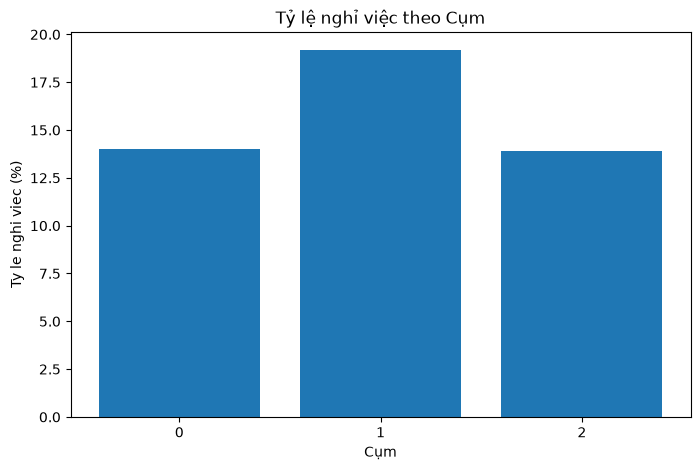

In [21]:
#Biểu đồ tỷ lệ theo việc từng cụm
plt.figure(figsize=(8, 5))

plt.bar(
    thong_ke_cum.index.astype(str),
    thong_ke_cum["TyLeNghiViec"]
)

plt.xlabel("Cụm")
plt.ylabel("Ty le nghi viec (%)")
plt.title("Tỷ lệ nghỉ việc theo Cụm")

plt.show()

In [22]:
ten_cum = {
    0: "Tham nien thap - Thu nhap thap",
    1: "Tham nien cao - Cham thang chuc",
    2: "Cap bac cao - thu nhap cao"
}

df_latest["TenCum"] = df_latest["Cluster"].map(ten_cum)

df_latest[["MaNV", "Cluster", "TenCum"]].head()

,MaNV,Cluster,TenCum
35210,1,0,Tham nien thap - Thu nhap thap
35211,3,0,Tham nien thap - Thu nhap thap
35212,4,0,Tham nien thap - Thu nhap thap
35213,5,2,Cap bac cao - thu nhap cao
35214,10,2,Cap bac cao - thu nhap cao


In [25]:
bao_cao_cum = thong_ke_cum[
    [   
        "SoNhanVien",
        "SoNghiViec",
        "TyLeNghiViec",
        "TuoiTB",
        "KhoangCachTB",
        "ThuNhapTB",
        "GioLamTB",
        "SoDuAnTB",
        "TyLeLamThem",
        "HaiLongCongViecTB",
        "HaiLongMoiTruongTB",
        "ThamNienTB",
        "NamTuThangChucTB"
    ]
].copy()

bao_cao_cum

,SoNhanVien,SoNghiViec,TyLeNghiViec,TuoiTB,KhoangCachTB,ThuNhapTB,GioLamTB,SoDuAnTB,TyLeLamThem,HaiLongCongViecTB,HaiLongMoiTruongTB,ThamNienTB,NamTuThangChucTB
Cluster,,,,,,,,,,,,,
0,2472,346,14.00,37.15,20.85,16647784.79,198.17,3.49,35.07,2.88,2.90,3.04,2.28
1,866,166,19.17,44.18,20.00,22307137.41,200.20,3.61,36.95,2.97,2.80,10.76,8.61
2,1093,152,13.91,40.13,20.28,48093792.31,198.02,3.50,35.68,2.85,2.86,6.73,2.92


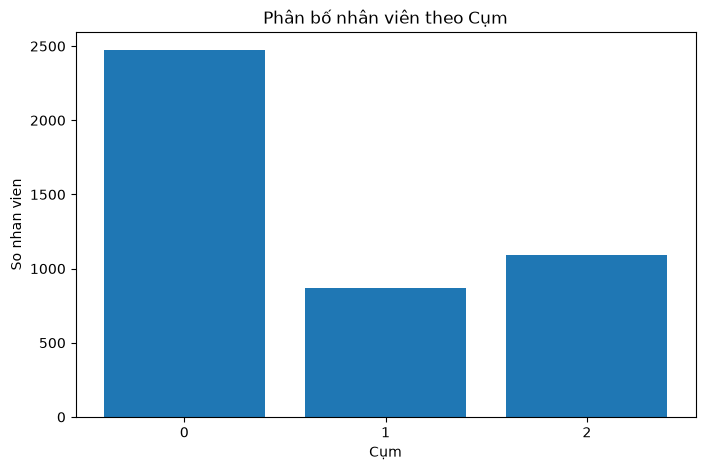

In [26]:
#Biểu đồ phân bố nhân viên theo từng cụm

plt.figure(figsize=(8, 5))

plt.bar(
    phan_bo_cum.index.astype(str),
    phan_bo_cum["SoNhanVien"]
)

plt.xlabel("Cụm")
plt.ylabel("So nhan vien")
plt.title("Phân bố nhân viên theo Cụm")

plt.show()

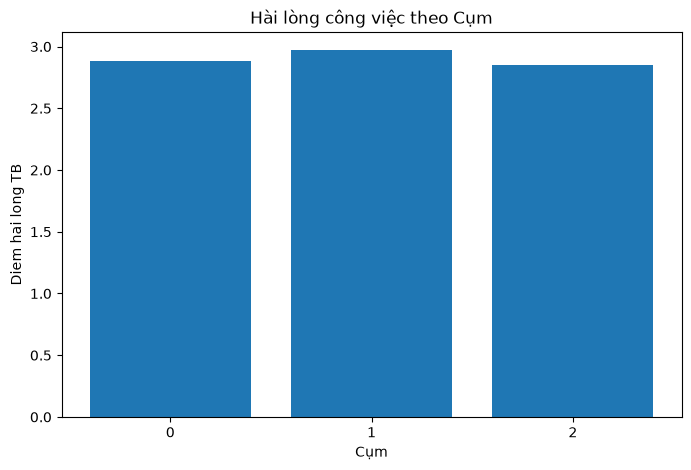

In [27]:
#Biểu đồ điểm hài lòng công việc theo từng cụm
plt.figure(figsize=(8, 5))

plt.bar(
    thong_ke_cum.index.astype(str),
    thong_ke_cum["HaiLongCongViecTB"]
)

plt.xlabel("Cụm")
plt.ylabel("Diem hai long TB")
plt.title("Hài lòng công việc theo Cụm")

plt.show()

In [28]:
#Lưu mô hình Kmeans
joblib.dump(
    scaler,
    MODEL_DIR / "scaler_kmeans.pkl"
)

['D:\\HR Analytics\\python\\models\\scaler_kmeans.pkl']

In [29]:
joblib.dump(
    k_mean,
    MODEL_DIR / "kmeans_model.pkl"
)

['D:\\HR Analytics\\python\\models\\kmeans_model.pkl']

In [31]:
ket_qua_phan_cum = df_latest[
    [
        "MaNV",
        "NgayThang",
        "PhongBan",
        "ChucDanh",
        "Cluster",
        "TenCum",
        "CoNghiViec"
    ]
].copy()

In [32]:
ket_qua_phan_cum.to_csv(
    OUTPUT_DIR / "ket_qua_phan_cum.csv",
    index=False,
    encoding="utf-8-sig"
)

In [33]:
thong_ke_cum.to_csv(
    OUTPUT_DIR / "tt_cum.csv",
    encoding="utf-8-sig"
)

In [36]:
centroid_thuc_te.round(2).to_csv(
    OUTPUT_DIR / "Cum_centroid_thuc_te.csv",
    encoding="utf-8-sig"
)

In [35]:
centroid_chuan_hoa.round(2).to_csv(
    OUTPUT_DIR / "Cum_centroid_chuan_hoa.csv",
    encoding="utf-8-sig"
)